#### Create client connection

In [10]:
%load_ext autoreload
%autoreload 2

from geosave_engine.geodata.stac import StacClient, StacQuery

client = StacClient.planetary_computer()
client.get_collections()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[<CollectionClient id=daymet-annual-pr>,
 <CollectionClient id=daymet-daily-hi>,
 <CollectionClient id=3dep-seamless>,
 <CollectionClient id=3dep-lidar-dsm>,
 <CollectionClient id=fia>,
 <CollectionClient id=gridmet>,
 <CollectionClient id=daymet-annual-na>,
 <CollectionClient id=daymet-monthly-na>,
 <CollectionClient id=daymet-annual-hi>,
 <CollectionClient id=daymet-monthly-hi>,
 <CollectionClient id=daymet-monthly-pr>,
 <CollectionClient id=gnatsgo-tables>,
 <CollectionClient id=hgb>,
 <CollectionClient id=cop-dem-glo-30>,
 <CollectionClient id=cop-dem-glo-90>,
 <CollectionClient id=terraclimate>,
 <CollectionClient id=nasa-nex-gddp-cmip6>,
 <CollectionClient id=gpm-imerg-hhr>,
 <CollectionClient id=gnatsgo-rasters>,
 <CollectionClient id=3dep-lidar-hag>,
 <CollectionClient id=io-lulc-annual-v02>,
 <CollectionClient id=goes-cmi>,
 <CollectionClient id=conus404>,
 <CollectionClient id=sentinel-1-rtc>,
 <CollectionClient id=3dep-lidar-intensity>,
 <CollectionClient id=3dep-lidar-point

#### Create query to search for stac items
Useful to know the properties of items for creating filters like cloud covers

In [11]:
query = StacQuery(
    collections=["sentinel-2-l2a"],
    bbox=(-5.0, 40.0, 5.0, 50.0),
    datetime="2023-01-01/2023-12-31",
    max_items=2,
)
items = client.search(query)
items[0].to_dict()

{'type': 'Feature',
 'stac_version': '1.1.0',
 'stac_extensions': ['https://stac-extensions.github.io/eo/v1.1.0/schema.json',
  'https://stac-extensions.github.io/sat/v1.0.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json'],
 'id': 'S2A_MSIL2A_20231231T105441_R051_T31UFR_20231231T162152',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[5.9064198, 50.5156646],
    [5.8637226, 50.4302952],
    [5.792411, 50.2859765],
    [5.7214025, 50.1416118],
    [5.6503657, 49.9972839],
    [5.5803346, 49.8528072],
    [5.5109418, 49.708286],
    [5.441884, 49.5637658],
    [5.4291558, 49.5371225],
    [4.3826844, 49.5564945],
    [4.4113495, 50.5437392],
    [5.9064198, 50.5156646]]]},
 'bbox': [4.38268436, 49.53712254, 5.90641984, 50.54373917],
 'properties': {'datetime': '2023-12-31T10:54:41.024000Z',
  'platform': 'Sentinel-2A',
  'instruments': ['msi'],
  's2:mgrs_tile': '31UFR',
  'constellation': 'Sentinel 2',
  's2:granule_id': 'S2A_OPER_MSI_L2A_TL_MSFT_2

#### Create connection to stac api collections
Establish the collection that we want to ingest, you can set the rule of ingestion here, like the bands, how the output dimension would be

In [12]:
source = client.source('sentinel-2-l2a')
source.get_bands_metadata().keys()

dict_keys(['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview'])

In [13]:
source = client.source(
    'sentinel-2-l2a',
    groupby="solar_day", # Group data when stitching stac items
    bands=["B04", "B03", "B02"], # RGB bands
    resampling="bilinear", # Resampling method, you can set it to nearest, cubic, or lanczos.
    max_nodata_fraction=0.01, # There might be missing pixel values, this parameter control the tolerance.
    temporal_granularity="day", # Aggregate data by day, you can set it to week, month, or year.
    temporal_reduce="first", # Take the first observation, you can set it to median, mean, or last.
    temporal_slots=1, # Useful if the dataset takes time series data, (B, T, H, W)
    temporal_strides=None, # If none then it follow temporal_slots, think if this like the interval for sampling
)

#### Ingest data from a location and time
Use GeoAnchor as the guide to download the data, we can build anchor from bbox, coordinate, , polygon, or geojson

[########################################] | 100% Completed | 3.86 sms
Area of the tile: 25000000.0 m2


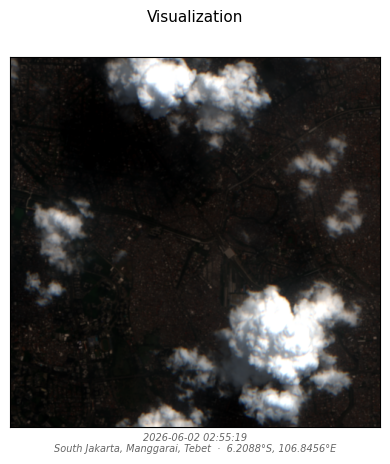

In [14]:
from geosave_engine.geodata.tile import GeoAnchor

lat, lon  = -6.2088, 106.8456  # Center coordinate (latitude, longitude) for Jakarta, Indonesia
size_m = 5000 # Produce 5km tile
resolution_m = 10 # Each pixel represents 10 m
datetime = "2026-06" # Will be interpreted as 2026-06-01T00:00:00Z to 2026-06-30T23:59:59Z

anchor = GeoAnchor.from_coordinate(lat, lon, size_m=size_m, resolution=resolution_m, datetime=datetime)
ingest_iter = source.load(anchor)
tile = next(ingest_iter)

tile.plot(title="Visualization")
print("Area of the tile:", anchor.area_m2, "m2")

[########################################] | 100% Completed | 3.55 sms
[########################################] | 100% Completed | 4.46 sms
[########################################] | 100% Completed | 7.91 sms
[########################################] | 100% Completed | 6.39 sms
[########################################] | 100% Completed | 4.56 sms
[########################################] | 100% Completed | 3.45 sms
[########################################] | 100% Completed | 4.67 sms


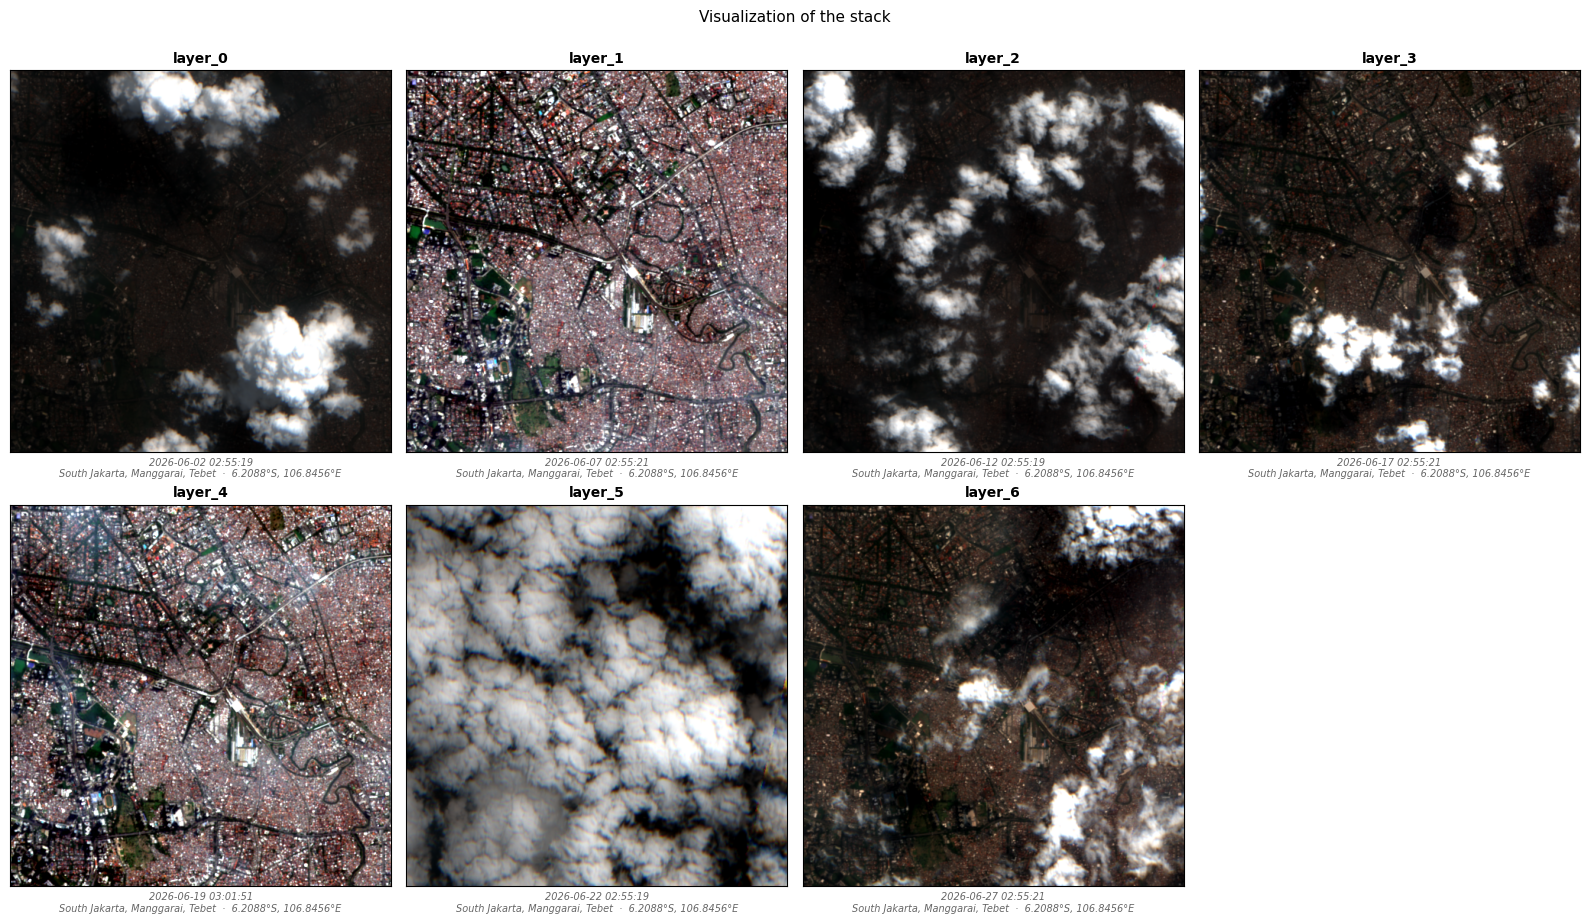

In [15]:
from geosave_engine.geodata.tile import GeoStack

# Get all tiles within a specified time range of the anchor
ingest_iter = source.load(anchor)
tiles = list(ingest_iter)
stack = GeoStack(*tiles)

stack.plot(title="Visualization of the stack");

[########################################] | 100% Completed | 2.13 sms
[########################################] | 100% Completed | 2.65 sms
[########################################] | 100% Completed | 3.45 sms


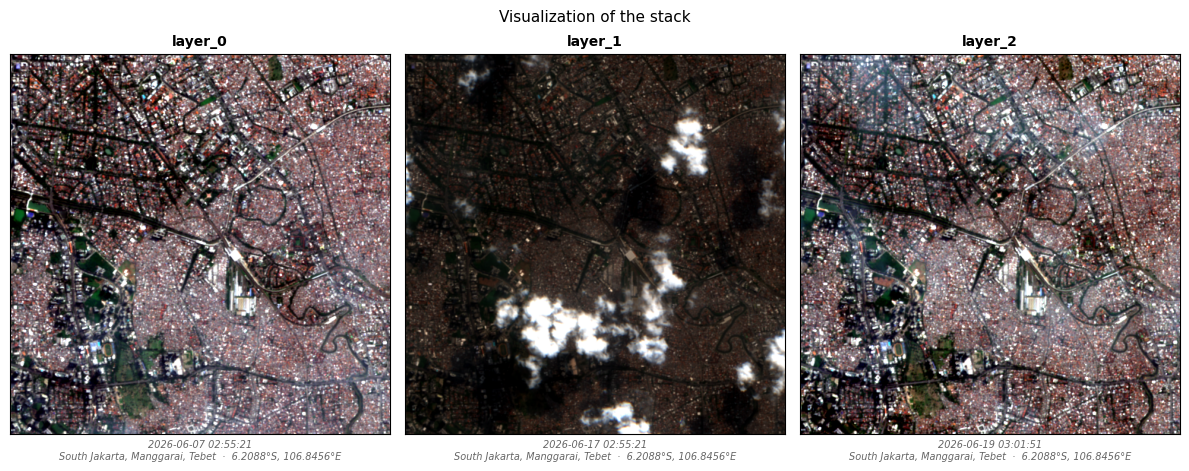

In [16]:
filter_source = source.set_filter("eo:cloud_cover <= 10") # Less than 10% cloud cover
ingest_iter = filter_source.load(anchor)
tiles = list(ingest_iter)
stack = GeoStack(*tiles)

stack.plot(title="Visualization of the stack");

[########################################] | 100% Completed | 811.61 ms
[########################################] | 100% Completed | 2.33 sms
[########################################] | 100% Completed | 819.60 ms
[########################################] | 100% Completed | 2.23 sms
[########################################] | 100% Completed | 2.33 sms
[########################################] | 100% Completed | 711.81 ms
[########################################] | 100% Completed | 1.02 sms
Area of the KHDTK Wanadipa polygon: 989817.1746974202 m2


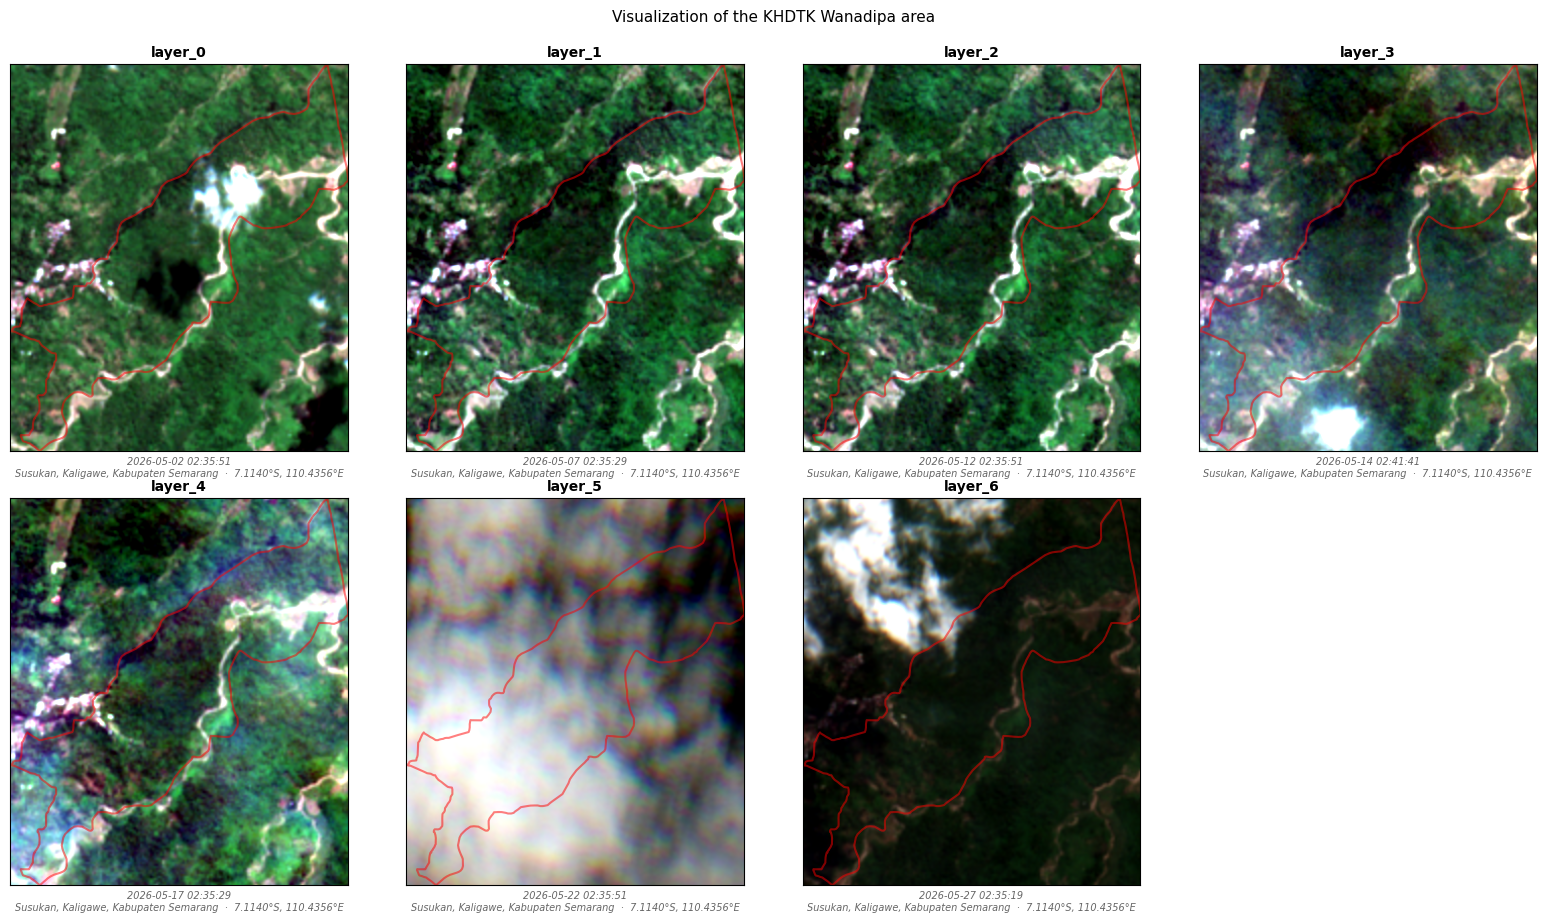

In [17]:
geojson = "data/khdtk_wanadipa_batas.geojson"

anchor_khdtk = next(GeoAnchor.from_geojson(geojson, resolution=5, datetime="2026-05"))
ingest_iter = source.load(anchor_khdtk)
tiles_khdtk = list(ingest_iter)
stack_khdtk = GeoStack(*tiles_khdtk)

stack_khdtk.plot(title="Visualization of the KHDTK Wanadipa area", polygon_alpha=0.5)

print("Area of the KHDTK Wanadipa polygon:", anchor_khdtk.area_m2, "m2")

In [18]:
from pystac_client import Client
# This works universally for any STAC API, StacClient will manage error handling for you

custom_client = Client.open("https://stac.dataspace.copernicus.eu/v1/")
stac_client = StacClient(custom_client)